# DATA CLEANING , MERGING AND FINAL MODELLING DATA SET 

In [1]:
# install dependancies

import os
from pathlib import Path
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# get the whole pandas dataframe to show

pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 1000); pd.set_option('display.width', 1000)

pd.options.display.max_columns = None
pd.options.display.max_rows = None


#get the parent directory of the current file
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)


# get the path to the data folder
data_path = os.path.join(
    parent_dir,
    "Data sets"
)


## 1. LOAD ALL RAW  DATA SETS , EVALUATE & JOIN THEM

* We have several raw data sets being used each with its own purpose which are :
  1. LSMS-ISA as the core farmer/household backbone
  2. The Kaggle mobile money datasets  are transaction-level.(THEY DONT HAVE real LSMS household IDs ,  so we'll create synthetic linkage)
  3. SAGDA Augmentation

### 1.1 HANDLE THE LSMS-ISA DATA SET 

 * For this we'll use the Living Standards Measurement Study (LSMS) by world bank group (https://microdata.worldbank.org/index.php/catalog/6410)
 * Its is categorized into three and we'll have to join them together using the key schema below :
    ![How to Join.png](<attachment:How to Join.png>)
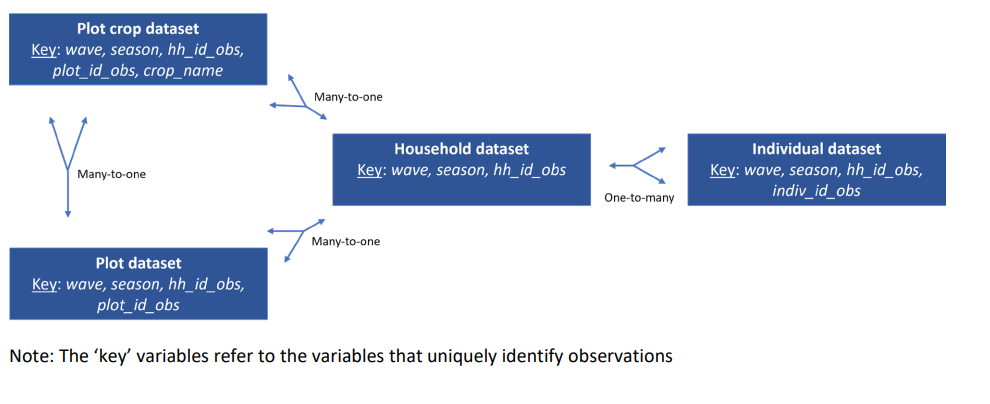

#### a) LOAD THE DATA SETS

In [2]:
# Load the data household dataset
household_data = pd.read_stata(os.path.join(data_path, "Raw data/LSMS-ISA-harmonised-dataset/Data/Household_dataset.dta"))

C:\Users\compweb\AppData\Local\Temp\ipykernel_8256\71059265.py:2: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  household_data = pd.read_stata(os.path.join(data_path, "Raw data/LSMS-ISA-harmonised-dataset/Data/Household_dataset.dta"))


In [3]:
#### Load the data Individual dataset
individual_data = pd.read_stata(os.path.join(data_path, "Raw data/LSMS-ISA-harmonised-dataset/Data/Individual_dataset.dta"))

C:\Users\compweb\AppData\Local\Temp\ipykernel_8256\4170076661.py:2: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  individual_data = pd.read_stata(os.path.join(data_path, "Raw data/LSMS-ISA-harmonised-dataset/Data/Individual_dataset.dta"))


In [4]:
#### Read the data plot dataset
plot_data = pd.read_stata(os.path.join(data_path, "Raw data/LSMS-ISA-harmonised-dataset/Data/Plot_dataset.dta"))

C:\Users\compweb\AppData\Local\Temp\ipykernel_8256\253511453.py:2: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  plot_data = pd.read_stata(os.path.join(data_path, "Raw data/LSMS-ISA-harmonised-dataset/Data/Plot_dataset.dta"))


In [5]:
# Load the plotcrop dataset
plotcrop_data = pd.read_stata(os.path.join(data_path, "Raw data/LSMS-ISA-harmonised-dataset/Data/Plotcrop_dataset.dta"))

C:\Users\compweb\AppData\Local\Temp\ipykernel_8256\977700141.py:2: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  plotcrop_data = pd.read_stata(os.path.join(data_path, "Raw data/LSMS-ISA-harmonised-dataset/Data/Plotcrop_dataset.dta"))


### b) DATA SETS EVALUATION


In [6]:

print("Household dataset shape:", household_data.shape)


Household dataset shape: (148421, 33)


In [7]:
print("Household dataset info:" , household_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148421 entries, 0 to 148420
Data columns (total 33 columns):
 #   Column                 Non-Null Count   Dtype   
---  ------                 --------------   -----   
 0   country                148421 non-null  object  
 1   wave                   148421 non-null  float64 
 2   hh_id_merge            148421 non-null  object  
 3   hh_id_obs              148421 non-null  float64 
 4   season                 148421 non-null  float64 
 5   pw                     147433 non-null  float64 
 6   ea_id_merge            148421 non-null  object  
 7   ea_id_obs              129411 non-null  float64 
 8   strataid               134284 non-null  float64 
 9   urban                  148373 non-null  category
 10  admin_1                148415 non-null  category
 11  admin_2                136622 non-null  float64 
 12  admin_3                124985 non-null  float64 
 13  admin_1_name           148421 non-null  object  
 14  admin_2_name        

In [8]:
print("House hold dataset columns " ,  household_data.columns)

House hold dataset columns  Index(['country', 'wave', 'hh_id_merge', 'hh_id_obs', 'season', 'pw', 'ea_id_merge', 'ea_id_obs', 'strataid', 'urban', 'admin_1', 'admin_2', 'admin_3', 'admin_1_name', 'admin_2_name', 'lat_modified', 'lon_modified', 'geocoords_id', 'hh_size', 'hh_shock', 'hh_primary_education', 'hh_electricity_access', 'hh_dependency_ratio', 'hh_formal_education', 'nonfarm_enterprise', 'nb_fallow_plots', 'nb_plots', 'share_kg_sold', 'totcons_LCU', 'totcons_USD', 'cons_quint', 'hh_asset_index', 'HDDS'], dtype='object')


In [9]:
print("Household dataset null values:", household_data.isnull().sum())


Household dataset null values: country                      0
wave                         0
hh_id_merge                  0
hh_id_obs                    0
season                       0
pw                         988
ea_id_merge                  0
ea_id_obs                19010
strataid                 14137
urban                       48
admin_1                      6
admin_2                  11799
admin_3                  23436
admin_1_name                 0
admin_2_name                 0
lat_modified             37344
lon_modified             37344
geocoords_id             37344
hh_size                   1177
hh_shock                  6147
hh_primary_education      4646
hh_electricity_access     1389
hh_dependency_ratio        763
hh_formal_education       1661
nonfarm_enterprise        5688
nb_fallow_plots          50546
nb_plots                 42478
share_kg_sold            86457
totcons_LCU              25269
totcons_USD              25269
cons_quint               25269
hh_asset

In [10]:
print("Household dataset duplicates:", household_data.duplicated().sum())

Household dataset duplicates: 0


* House Hold data set summary statistics
 1. The data set has 148421 rows and 33 columns.
 2. The dataset contains a mix of numeric and categorical variables.
 3. There are some missing values in the dataset, with the number of missing values varying across different columns. 
 4. The dataset does not contain any duplicate rows.

In [11]:
individual_data.shape

(873790, 46)

In [12]:
individual_data.columns

Index(['country', 'wave', 'season', 'hh_id_obs', 'hh_id_merge', 'indiv_id_obs', 'indiv_id_merge', 'pw', 'ea_id_merge', 'ea_id_obs', 'strataid', 'urban', 'admin_1', 'admin_2', 'admin_3', 'admin_1_name', 'admin_2_name', 'lat_modified', 'lon_modified', 'geocoords_id', 'relationship_head', 'age', 'married', 'female', 'formal_education', 'primary_education', 'height', 'weight', 'wasting', 'haz06', 'waz06', 'whz06', 'bmiz06', 'farm_work', 'SOB_work', 'wage_work', 'farm_hrs', 'SB_hrs', 'wage_hrs', 'ind_ag', 'ind_fish', 'ind_mining', 'ind_manuf', 'ind_const', 'ind_serv', 'working_age'], dtype='object')

In [13]:
individual_data.isnull().sum()

country                   0
wave                      0
season                    0
hh_id_obs              1000
hh_id_merge               0
indiv_id_obs              0
indiv_id_merge            0
pw                     2293
ea_id_merge               0
ea_id_obs            100146
strataid              71440
urban                  1035
admin_1                1012
admin_2               85861
admin_3              147256
admin_1_name              0
admin_2_name              0
lat_modified         200319
lon_modified         200319
geocoords_id         200319
relationship_head         0
age                   30962
married               50216
female                11874
formal_education      84892
primary_education    118807
height               751157
weight               751106
wasting              752190
haz06                751954
waz06                751952
whz06                752190
bmiz06               802090
farm_work             23052
SOB_work              23472
wage_work           

In [14]:
individual_data.duplicated().sum()

np.int64(0)

* Individual data set summary statistics
 1. The data set has 873790 rows and 46 columns.
 2. The dataset contains a mix of numeric and categorical variables.
 3. There are some missing values in the dataset, with the number of missing values varying across different columns. 
 4. The dataset does not contain any duplicate rows.

In [15]:
#plot_data.info

In [16]:
plot_data.shape

# The dataset has 263195 rows and 115 columns

(263195, 115)

In [17]:
plot_data.columns

Index(['country', 'wave', 'hh_id_obs', 'hh_id_merge', 'plot_id_obs', 'plot_id_merge', 'parcel_id_obs', 'parcel_id_merge', 'season', 'pw',
       ...
       'rooting_conditions', 'oxygen_availability', 'excess_salts', 'toxicity', 'workability', 'soil_fertility_index', 'plot_dist_household', 'plot_slope', 'main_crop', 'plot_area_GPS_1_'], dtype='object', length=115)

In [18]:
plot_data.isnull().sum()

country                                0
wave                                   0
hh_id_obs                            773
hh_id_merge                            0
plot_id_obs                            0
plot_id_merge                          0
parcel_id_obs                     124502
parcel_id_merge                        0
season                                 0
pw                                   844
ea_id_merge                            0
ea_id_obs                          22722
strataid                           17266
admin_1                            56653
admin_2                            57594
admin_3                            62234
admin_1_name                           0
admin_2_name                           0
lat_modified                       57910
lon_modified                       57910
geocoords_id                       57910
harvest_interview_month            17404
planting_interview_month          100056
plot_area_GPS                      14036
farm_size       

In [19]:
plot_data.duplicated().sum()

np.int64(0)

* Plot data set summary statistics
 1. The dataset has 263195 rows and 115 columns
 2. The dataset contains a mix of numeric and categorical variables.
 3. There are some missing values in the dataset, with the number of missing values varying across different columns. 
 4. The dataset does not contain any duplicate rows.

In [20]:
plotcrop_data.info

KeyboardInterrupt: 

In [ ]:
plotcrop_data.describe

<bound method NDFrame.describe of          country  wave  crop_name  season           pw      ea_id_merge  ea_id_obs  strataid urban admin_1  admin_2  admin_3 admin_1_name admin_2_name  admin_3_name  lat_modified  lon_modified  geocoords_id  parcel_id_obs                     parcel_id_merge  plot_id_obs                         plot_id_merge  hh_id_obs                       hh_id_merge    harvest_end_month       planting_month  harvest_kg  harvest_value_LCU  harvest_value_USD  seed_kg  seed_value_LCU  seed_value_USD improved used_pesticides crop_shock  pests_shock  rain_shock  drought_shock flood_shock
0       Ethiopia   1.0    SORGHUM     1.0  2236.134521  010101088801601  1000002.0       7.0    No  Tigray     11.0    111.0       Tigray                                14.353816     37.890876     1001574.0      1000019.0                  0101010160100201-1    1000001.0                  0101010160100201-1-4  1000013.0                    01010101601002  2011-11-01 00:00:00  2011-06-01 00:0

In [ ]:
plotcrop_data.columns

Index(['country', 'wave', 'crop_name', 'season', 'pw', 'ea_id_merge', 'ea_id_obs', 'strataid', 'urban', 'admin_1', 'admin_2', 'admin_3', 'admin_1_name', 'admin_2_name', 'admin_3_name', 'lat_modified', 'lon_modified', 'geocoords_id', 'parcel_id_obs', 'parcel_id_merge', 'plot_id_obs', 'plot_id_merge', 'hh_id_obs', 'hh_id_merge', 'harvest_end_month', 'planting_month', 'harvest_kg', 'harvest_value_LCU', 'harvest_value_USD', 'seed_kg', 'seed_value_LCU', 'seed_value_USD', 'improved', 'used_pesticides', 'crop_shock', 'pests_shock', 'rain_shock', 'drought_shock', 'flood_shock'], dtype='object')

In [ ]:
plotcrop_data.shape

(514665, 39)

In [ ]:
plotcrop_data.isnull().sum()


country                   0
wave                      0
crop_name                 0
season                    0
pw                     1735
ea_id_merge               0
ea_id_obs             62527
strataid              46934
urban                  1082
admin_1                1061
admin_2               57431
admin_3               98727
admin_1_name              0
admin_2_name              0
admin_3_name              0
lat_modified         119366
lon_modified         119366
geocoords_id         119366
parcel_id_obs        147894
parcel_id_merge           0
plot_id_obs               0
plot_id_merge             0
hh_id_obs              1512
hh_id_merge               0
harvest_end_month    161193
planting_month       201172
harvest_kg            62155
harvest_value_LCU     69328
harvest_value_USD     69328
seed_kg              217596
seed_value_LCU       259017
seed_value_USD       259017
improved             228182
used_pesticides       24490
crop_shock            64797
pests_shock         

In [ ]:
plotcrop_data.duplicated().sum()

np.int64(0)

* Plot crop data set summary statistics
 1. The dataset has 514665 rows x 39 columns
 2. The dataset contains a mix of numeric and categorical variables.
 3. There are some missing values in the dataset, with the number of missing values varying across different columns. 
 4. The dataset does not contain any duplicate rows.

### c) MERGE THE FOUR LSMS DATA SETS 

 #### 1. Merge Household and Plot
 * Join them  on: wave, season, hh_id_obs

In [21]:
# Example check for the Plot dataset
is_unique = not plot_data.duplicated(subset=['wave', 'season', 'hh_id_obs', 'plot_id_obs']).any()
print(f"Plot keys are unique: {is_unique}")

Plot keys are unique: True


In [22]:
# check for the HOUSEHOLD dataset
is_unique = not household_data.duplicated(subset=['wave', 'season', 'hh_id_obs']).any()
print(f"Plot keys are unique: {is_unique}")

Plot keys are unique: True


In [23]:
household_data.shape


(148421, 33)

In [24]:
plot_data.shape

(263195, 115)

In [25]:
print(263195 + 148421)

411616


In [26]:

master_df = pd.merge(
    household_data, 
    plot_data, 
    on=['wave', 'season', 'hh_id_obs'], 
    how='left'
)

In [27]:
# Check why plot data isn't matching household data
check_merge = pd.merge(
    household_data, 
    plot_data, 
    on=['wave', 'season', 'hh_id_obs'], 
    how='outer', 
    indicator=True
)

# See how many didn't match
print(check_merge['_merge'].value_counts())

# See the households that have NO plot data
missing_plots = check_merge[check_merge['_merge'] == 'left_only']

_merge
both          262422
left_only      53870
right_only       773
Name: count, dtype: int64


In [28]:
master_df.shape

(316292, 145)

#### 2. Merge the Plot Crop data
* Join them on: wave, season, hh_id_obs, AND plot_id_obs


In [29]:
# Including 'crop_name' as per the diagram's key definition
is_unique = not plotcrop_data.duplicated(subset=['wave', 'season', 'hh_id_obs', 'plot_id_obs', 'crop_name']).any()

print(f"Plot-Crop keys are unique: {is_unique}")

Plot-Crop keys are unique: True


In [30]:
master_df.shape

(316292, 145)

In [31]:
plotcrop_data.shape

(514665, 39)

In [32]:
print(316292 + 514665)

830957


In [33]:
master_df = pd.merge(
    master_df, 
    plotcrop_data, 
    on=['wave', 'season', 'hh_id_obs', 'plot_id_obs'], 
    how='left'
)

In [34]:
master_df.shape

(442137, 180)

In [35]:
# Identify columns that are in both but aren't keys
common_cols = [c for c in plotcrop_data.columns if c in master_df.columns]
keys = ['wave', 'season', 'hh_id_obs', 'plot_id_obs']
cols_to_drop = [c for c in common_cols if c not in keys]

# Drop them from the crop data before merging
plotcrop_data_clean = plotcrop_data.drop(columns=cols_to_drop)

# Now merge without suffix errors
check_merge = pd.merge(
    master_df, 
    plotcrop_data_clean, 
    on=keys, 
    how='outer', 
    indicator=True
)
# See how many didn't match
print(check_merge['_merge'].value_counts())

# See the households that have NO plot data
missing_plots = check_merge[check_merge['_merge'] == 'left_only']

_merge
both          833131
right_only    182666
left_only     110138
Name: count, dtype: int64


#### 3. Merge the Individual data
* Join on: wave, season, hh_id_obs
* Note: This will create a row for every person/crop combination

In [36]:
individual_data.shape

(873790, 46)

In [37]:
master_df.shape

(442137, 180)

In [38]:
pd.set_option('display.max_rows', 1000); pd.set_option('display.max_columns', 1000); pd.set_option('display.width', 1000)
master_df.columns


Index(['country_x', 'wave', 'hh_id_merge_x', 'hh_id_obs', 'season', 'pw_x', 'ea_id_merge_x', 'ea_id_obs_x', 'strataid_x', 'urban_x',
       ...
       'seed_kg_y', 'seed_value_LCU_y', 'seed_value_USD_y', 'improved_y', 'used_pesticides_y', 'crop_shock_y', 'pests_shock_y', 'rain_shock_y', 'drought_shock_y', 'flood_shock_y'], dtype='object', length=180)

In [39]:
# 1) Identify merge keys
keys = ['wave', 'season', 'hh_id_obs']

# 2) Drop overlapping non-key columns
overlapping_cols = [col for col in individual_data.columns 
                    if col in master_df.columns and col not in keys]

individual_data_clean = individual_data.drop(columns=overlapping_cols).copy()

# 3) Ensure right side is unique per key
individual_data_clean = individual_data_clean.drop_duplicates(subset=keys).copy()

# 4) Keep only needed columns
add_cols = [
    'country', 'wave', 'season', 'age', 'hh_id_obs', 'married', 'female',
    'formal_education', 'primary_education',
    'farm_work', 'SOB_work', 'wage_work',
    'farm_hrs', 'SB_hrs', 'wage_hrs',
    'working_age'
]

# Keep only columns that actually exist
cols_to_add = [c for c in add_cols if c in individual_data_clean.columns]

individual_data_small = individual_data_clean.loc[:, cols_to_add].copy()

# 5) Downcast floats to reduce memory
for df in [master_df, individual_data_small]:
    float_cols = df.select_dtypes(include=["float64"]).columns
    if len(float_cols) > 0:
        df.loc[:, float_cols] = df.loc[:, float_cols].astype("float32")

# Optional: downcast ints too
for df in [master_df, individual_data_small]:
    int_cols = df.select_dtypes(include=["int64"]).columns
    if len(int_cols) > 0:
        df.loc[:, int_cols] = df.loc[:, int_cols].apply(pd.to_numeric, downcast="integer")

# 6) Merge with validation
try:
    final_agri_df = master_df.merge(
        individual_data_small,
        on=keys,
        how="left",
        validate="many_to_one",
        sort=False
    )
    print("Final merge successful!")
    print(final_agri_df.shape)

except Exception as e:
    print(type(e).__name__)
    print(e)

Final merge successful!
(442137, 192)


In [40]:

pd.options.display.max_columns = None
pd.options.display.max_rows = None


In [41]:
final_agri_df.head(1)

,country_x,wave,hh_id_merge_x,hh_id_obs,season,pw_x,ea_id_merge_x,ea_id_obs_x,strataid_x,urban_x,admin_1_x,admin_2_x,admin_3_x,admin_1_name_x,admin_2_name_x,lat_modified_x,lon_modified_x,geocoords_id_x,hh_size,hh_shock,hh_primary_education,hh_electricity_access,hh_dependency_ratio,hh_formal_education,nonfarm_enterprise,nb_fallow_plots,nb_plots,share_kg_sold,totcons_LCU,totcons_USD,cons_quint,hh_asset_index,HDDS,country_y,hh_id_merge_y,plot_id_obs,plot_id_merge_x,parcel_id_obs_x,parcel_id_merge_x,pw_y,ea_id_merge_y,ea_id_obs_y,strataid_y,admin_1_y,admin_2_y,admin_3_y,admin_1_name_y,admin_2_name_y,lat_modified_y,lon_modified_y,geocoords_id_y,harvest_interview_month,planting_interview_month,plot_area_GPS,farm_size,harvest_kg_x,harvest_value_LCU_x,harvest_value_USD_x,yield_kg,yield_value_LCU,yield_value_USD,total_labor_days,total_hired_labor_days,total_family_labor_days,hired_labor_value_LCU,hired_labor_value_USD,seed_kg_x,seed_value_LCU_x,seed_value_USD_x,improved_x,nitrogen_kg,inorganic_fertilizer,inorganic_fertilizer_value_LCU,inorganic_fertilizer_value_USD,organic_fertilizer,used_pesticides_x,crop_shock_x,drought_shock_x,rain_shock_x,pests_shock_x,flood_shock_x,intercropped,nb_seasonal_crop,maincrop_valueshare,share_value_BARLEY,share_value_LEGUMES,share_value_MAIZE,share_value_MILLET,share_value_NUTS,share_value_OTHER,share_value_PERENNIAL,share_value_RICE,share_value_SORGHUM,share_value_TUBERS,share_value_WHEAT,contains_BARLEY,contains_LEGUMES,contains_MAIZE,contains_MILLET,contains_OTHER,contains_PERENNIALS,contains_RICE,contains_SORGHUM,contains_TUBERS,contains_WHEAT,contains_NUTS,manager_id_merge,manager_id_obs,age_manager,female_manager,married_manager,formal_education_manager,primary_education_manager,respondent_id_merge,respondent_id_obs,age_respondent,female_respondent,married_respondent,formal_education_respondent,primary_education_respondent,irrigated,tractor,erosion_protection,plot_owned,plot_certificate,livestock,urban_y,ag_asset_index,agro_ecological_zone,dist_popcenter,dist_market,elevation,twi,nutrient_availability,nutrient_retention,rooting_conditions,oxygen_availability,excess_salts,toxicity,workability,soil_fertility_index,plot_dist_household,plot_slope,main_crop,plot_area_GPS_1_,country,crop_name,pw,ea_id_merge,ea_id_obs,strataid,urban,admin_1,admin_2,admin_3,admin_1_name,admin_2_name,admin_3_name,lat_modified,lon_modified,geocoords_id,parcel_id_obs_y,parcel_id_merge_y,plot_id_merge_y,hh_id_merge,harvest_end_month,planting_month,harvest_kg_y,harvest_value_LCU_y,harvest_value_USD_y,seed_kg_y,seed_value_LCU_y,seed_value_USD_y,improved_y,used_pesticides_y,crop_shock_y,pests_shock_y,rain_shock_y,drought_shock_y,flood_shock_y,age,married,female,formal_education,primary_education,farm_work,SOB_work,wage_work,farm_hrs,SB_hrs,wage_hrs,working_age
0,Ethiopia,1.0,01010101601162,1000001.0,1.0,1887.646118,010101088801601,1000002.0,7.0,No,Tigray,11.0,111.0,Tigray,,14.353816,37.890877,1001574.0,2.0,0.0,0.0,Yes,1.0,1.0,1.0,0.0,0.0,NaN,4228.026367,301.78009,4.0,5.598237,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,Yes,Yes,No,No,1.0,1.0,0.0,10.0,20.0,0.0,1.0


###  d) REDUCE ONLY NEEDED FEATURES (LSMS  MERGED DATASET)

 * Reduce redundant features from the merges , reduce irrelevant features since 10 columns are too many and make the model be noisy 

In [42]:
# S Work on a copy

df = final_agri_df.copy()

In [43]:
df.shape

(442137, 192)

In [44]:
#  Clean up suffixes from older merges


#  Drop lingering '_y' columns

y_cols = [c for c in df.columns if c.endswith('_y')]
df = df.drop(columns=y_cols, errors='ignore')

# Rename '_x' columns back to original names
df.columns = df.columns.str.replace(r'_x$', '', regex=True)

#  Drop duplicate column names
# Keeps the first occurrence, which is usually what you want
# if LSMS/master_df was the left/base dataframe in the merge

df = df.loc[:, ~df.columns.duplicated()].copy()

In [45]:
df.shape

(442137, 146)

In [46]:
df.columns.tolist()

['country',
 'wave',
 'hh_id_merge',
 'hh_id_obs',
 'season',
 'pw',
 'ea_id_merge',
 'ea_id_obs',
 'strataid',
 'urban',
 'admin_1',
 'admin_2',
 'admin_3',
 'admin_1_name',
 'admin_2_name',
 'lat_modified',
 'lon_modified',
 'geocoords_id',
 'hh_size',
 'hh_shock',
 'hh_primary_education',
 'hh_electricity_access',
 'hh_dependency_ratio',
 'hh_formal_education',
 'nonfarm_enterprise',
 'nb_fallow_plots',
 'nb_plots',
 'share_kg_sold',
 'totcons_LCU',
 'totcons_USD',
 'cons_quint',
 'hh_asset_index',
 'HDDS',
 'plot_id_obs',
 'plot_id_merge',
 'parcel_id_obs',
 'parcel_id_merge',
 'harvest_interview_month',
 'planting_interview_month',
 'plot_area_GPS',
 'farm_size',
 'harvest_kg',
 'harvest_value_LCU',
 'harvest_value_USD',
 'yield_kg',
 'yield_value_LCU',
 'yield_value_USD',
 'total_labor_days',
 'total_hired_labor_days',
 'total_family_labor_days',
 'hired_labor_value_LCU',
 'hired_labor_value_USD',
 'seed_kg',
 'seed_value_LCU',
 'seed_value_USD',
 'improved',
 'nitrogen_kg',
 'in

In [47]:
df.head(2)

,country,wave,hh_id_merge,hh_id_obs,season,pw,ea_id_merge,ea_id_obs,strataid,urban,admin_1,admin_2,admin_3,admin_1_name,admin_2_name,lat_modified,lon_modified,geocoords_id,hh_size,hh_shock,hh_primary_education,hh_electricity_access,hh_dependency_ratio,hh_formal_education,nonfarm_enterprise,nb_fallow_plots,nb_plots,share_kg_sold,totcons_LCU,totcons_USD,cons_quint,hh_asset_index,HDDS,plot_id_obs,plot_id_merge,parcel_id_obs,parcel_id_merge,harvest_interview_month,planting_interview_month,plot_area_GPS,farm_size,harvest_kg,harvest_value_LCU,harvest_value_USD,yield_kg,yield_value_LCU,yield_value_USD,total_labor_days,total_hired_labor_days,total_family_labor_days,hired_labor_value_LCU,hired_labor_value_USD,seed_kg,seed_value_LCU,seed_value_USD,improved,nitrogen_kg,inorganic_fertilizer,inorganic_fertilizer_value_LCU,inorganic_fertilizer_value_USD,organic_fertilizer,used_pesticides,crop_shock,drought_shock,rain_shock,pests_shock,flood_shock,intercropped,nb_seasonal_crop,maincrop_valueshare,share_value_BARLEY,share_value_LEGUMES,share_value_MAIZE,share_value_MILLET,share_value_NUTS,share_value_OTHER,share_value_PERENNIAL,share_value_RICE,share_value_SORGHUM,share_value_TUBERS,share_value_WHEAT,contains_BARLEY,contains_LEGUMES,contains_MAIZE,contains_MILLET,contains_OTHER,contains_PERENNIALS,contains_RICE,contains_SORGHUM,contains_TUBERS,contains_WHEAT,contains_NUTS,manager_id_merge,manager_id_obs,age_manager,female_manager,married_manager,formal_education_manager,primary_education_manager,respondent_id_merge,respondent_id_obs,age_respondent,female_respondent,married_respondent,formal_education_respondent,primary_education_respondent,irrigated,tractor,erosion_protection,plot_owned,plot_certificate,livestock,ag_asset_index,agro_ecological_zone,dist_popcenter,dist_market,elevation,twi,nutrient_availability,nutrient_retention,rooting_conditions,oxygen_availability,excess_salts,toxicity,workability,soil_fertility_index,plot_dist_household,plot_slope,main_crop,plot_area_GPS_1_,crop_name,admin_3_name,harvest_end_month,planting_month,age,married,female,formal_education,primary_education,farm_work,SOB_work,wage_work,farm_hrs,SB_hrs,wage_hrs,working_age
0,Ethiopia,1.0,01010101601162,1000001.0,1.0,1887.646118,010101088801601,1000002.0,7.0,No,Tigray,11.0,111.0,Tigray,,14.353816,37.890877,1001574.0,2.0,0.0,0.0,Yes,1.000000,1.0,1.0,0.0,0.0,NaN,4228.026367,301.780090,4.0,5.598237,5.0,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,Yes,Yes,No,No,1.0,1.0,0.0,10.0,20.0,0.0,1.0
1,Ethiopia,1.0,01010101601002,1000013.0,1.0,2236.134521,010101088801601,1000002.0,7.0,No,Tigray,11.0,111.0,Tigray,,14.353816,37.890877,1001574.0,8.0,0.0,0.0,No,1.333333,1.0,0.0,0.0,9.0,0.0,2336.555908,166.774277,2.0,0.241174,6.0,1000001.0,0101010160100201-1-4,1000019.0,0101010160100201-1,2012-02-01,2011-10-01,0.1309,1.0626,600.0,2840.0,202.70816,4583.651855,21695.951172,1548.572632,17.0,2.0,15.0,205.0,14.632103,11.36,90.879997,6.486661,0.0,0.0,Yes,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,No,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0101010160100201,1000068.0,77.0,Yes,No,No,No,0101010160100201,1000068.0,77.0,Yes,No,No,No,No,NaN,NaN,Yes,Yes,Yes,0.176076,Tropic-warm/semiarid,53.200001,105.300003,1103.0,13.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.697196,NaN,NaN,SORGHUM,0.1309,SORGHUM,,2011-11-01 00:00:00,2011-06-01 00:00:00,18.0,No,No,No,No,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [48]:

# LSMS-ISA BEST FEATURES - CLEAN & GROUPED (High Signal, Low Noise)

# Survey Design & Weights (keep for analysis)
survey_design = [
    'countrywave', 'season', 'pw', 'strataid', 'urban'
]

# Household Identifiers (minimal - use mainly for grouping)
household_ids = [
    'hh_id_merge', 'hh_id_obs'
]

# 1. Household Composition & Demographics
household_composition = [
    'hh_size', 
    'hh_dependency_ratio',
    'age_manager', 
    'female_manager', 
    'married_manager',
    'age_respondent', 
    'female_respondent', 
    'married_respondent'
]

# 2. Education
education = [
    'hh_primary_education',
    'hh_formal_education'
]

# 3. Labor & Time Use
labor_time = [
    'total_labor_days',
    'total_hired_labor_days', 
    'total_family_labor_days',
    'farm_work', 
    'SOB_work', 
    'wage_work',
    'farm_hrs', 
    'working_ag'
]

# 4. Landholding & Tenure
landholding = [
    'nb_plots',
    'nb_fallow_plots',
    'farm_size',
    'plot_area_GPS',
    'plot_owned',
    'plot_certificate'
]

# 5. Plot / Agricultural Practices
plot_agriculture = [
    'irrigated',
    'intercropped',
    'main_crop',
    'maincrop_value',
    'yield_kg',
    'yield_value_USD',
    'harvest_value_USD',
    'share_kg_sold',
    'improved',
    'nitrogen_kg',
    'inorganic_fertilizer',
    'organic_fertilizer',
    'used_pesticides'
]

# 6. Livestock & Assets
livestock_assets = [
    'livestock',
    'hh_asset_index',
    'ag_asset_index'
]

# 7. Consumption & Income
consumption_income = [
    'totcons_USD',
    'totcons_LCU',
    'cons_quint',
    'nonfarm_enterprise',
    'HDDS'
]

# 8. Shocks & Risk
shocks = [
    'hh_shock',
    'crop_shock',
    'drought_shock',
    'rain_shock',
    'pests_shock',
    'flood_shock'
]

# 9. Location & Agro-ecological Context
location_context = [
    'agro_ecological_zone',
    'dist_popcenter',
    'dist_market',
    'soil_fertility_index'
]


# COMBINED CORE FEATURE LIST (≈25-30 best features for modeling)

core_features = (
    survey_design +
    household_composition +
    education +
    labor_time +
    landholding +
    plot_agriculture +
    livestock_assets +
    consumption_income +
    shocks +
    location_context
)

# Remove duplicates if any
core_features = list(dict.fromkeys(core_features))


In [49]:
#  Define compact agriscore backbone
core_agri_cols1 = [
    # survey / panel structure
    'country', 'wave', 'season', 'pw', 'strataid', 'urban',
    'hh_id_merge', 'hh_id_obs',

    # household structure
    'hh_size', 'hh_dependency_ratio',

    # farmer / manager traits
    'age_manager',
    'hh_primary_education', 'hh_formal_education',

    # labor / effort
    'working_ag', 'farm_work', 'SOB_work', 'wage_work',

    # land / farm structure
    'nb_plots', 'farm_size', 'plot_area_GPS',
    'plot_owned', 'plot_certificate',

    # production / practices
    'irrigated', 'intercropped', 'main_crop',
    'improved', 'inorganic_fertilizer', 'organic_fertilizer', 'used_pesticides',

    # assets / resilience
    'livestock', 'hh_asset_index',

    # shocks / risk
    'hh_shock', 'crop_shock', 'drought_shock', 'rain_shock', 'pests_shock', 'flood_shock',

    # location / context
    'agro_ecological_zone', 'dist_market', 'soil_fertility_index'
]

In [50]:
core_agri_cols_final = [
    # survey / panel structure
    'country', 'wave', 'season', 'pw', 'strataid', 'urban',
    'hh_id_merge', 'hh_id_obs',

    # household structure
    'hh_size', 'hh_dependency_ratio',

    # farmer / manager traits
    'age_manager',

    # education
    'hh_primary_education', 'hh_formal_education',

    # labor / effort
    'working_ag', 'farm_work',

    # land / farm structure
    'farm_size', 'plot_owned',

    # production / practices
    'irrigated', 'inorganic_fertilizer','main_crop', 'livestock',

    # shocks / risk
    'hh_shock', 'crop_shock', 'drought_shock',

    # location / context
    'dist_market'
]

In [51]:

#  remove repeated names in case the lists overlap
core_lsms_cols = list(dict.fromkeys(core_agri_cols_final))

In [52]:

# STEP 3: Keep only columns that exist
cols_to_keep = [col for col in core_lsms_cols if col in df.columns]
missing_cols = [col for col in core_lsms_cols if col not in df.columns]

# Final clean backbone dataframe
lsms_backbone_df = df.loc[:, cols_to_keep].copy()

# ==========================================
# STEP 4: Review
# ==========================================
print("✅ Cleanup Complete!")
print(f"Columns before cleanup: {len(final_agri_df.columns)}")
print(f"Columns after suffix cleanup: {len(df.columns)}")
print(f"Final backbone columns kept: {len(lsms_backbone_df.columns)}")

print("\nFinal Column List:")
print(lsms_backbone_df.columns.tolist())

if missing_cols:
    print("\nColumns requested but not found in dataframe:")
    print(missing_cols)
else:
    print("\nAll requested backbone columns were found.")

✅ Cleanup Complete!
Columns before cleanup: 192
Columns after suffix cleanup: 146
Final backbone columns kept: 24

Final Column List:
['country', 'wave', 'season', 'pw', 'strataid', 'urban', 'hh_id_merge', 'hh_id_obs', 'hh_size', 'hh_dependency_ratio', 'age_manager', 'hh_primary_education', 'hh_formal_education', 'farm_work', 'farm_size', 'plot_owned', 'irrigated', 'inorganic_fertilizer', 'main_crop', 'livestock', 'hh_shock', 'crop_shock', 'drought_shock', 'dist_market']

Columns requested but not found in dataframe:
['working_ag']


In [53]:
lsms_backbone_df.shape

(442137, 24)

In [54]:
print(lsms_backbone_df.columns.tolist())

['country', 'wave', 'season', 'pw', 'strataid', 'urban', 'hh_id_merge', 'hh_id_obs', 'hh_size', 'hh_dependency_ratio', 'age_manager', 'hh_primary_education', 'hh_formal_education', 'farm_work', 'farm_size', 'plot_owned', 'irrigated', 'inorganic_fertilizer', 'main_crop', 'livestock', 'hh_shock', 'crop_shock', 'drought_shock', 'dist_market']


In [55]:
print(lsms_backbone_df.isna().sum())

country                      0
wave                         0
season                       0
pw                        1030
strataid                 22024
urban                       74
hh_id_merge                  0
hh_id_obs                    0
hh_size                   1691
hh_dependency_ratio        768
age_manager              77637
hh_primary_education     10126
hh_formal_education       1831
farm_work                 3260
farm_size                64968
plot_owned               64820
irrigated                71469
inorganic_fertilizer     71898
main_crop                53870
livestock                60296
hh_shock                 19206
crop_shock               84049
drought_shock           150914
dist_market             294228
dtype: int64


In [58]:
lsms_backbone_df[['main_crop','livestock']].isnull().sum()

main_crop    53870
livestock    60296
dtype: int64

In [59]:
# save the lsms_backbone raw data set first 

df.to_csv( (os.path.join(data_path, "Raw data/LSMS-ISA-harmonised-dataset/Data/lsms_raw_featuresonly.csv")) , index=False)  


### e) CLEAN THE LSMS BACKBONE (NEEDED FEATURES ONLY DATAFRAME)
 * We do this in preparation of SAGDA augumentation

In [ ]:
# LOAD THE LSMS DATA SET

LSMS

In [61]:
# EVALUATE THE DATAFRAME 

